# Wind Power Forecasting — LSTM

Goal: forecast turbine power **1 hour ahead** with an LSTM (a deep learning model for sequences), and compare it with the XGBoost model from notebook 04.

To keep the comparison fair, the LSTM uses:
- the **same features** as the selected XGBoost model
- the **same target**: the *change* in power over the next hour
- the **same time-based split**: train Jan–Aug, validation Sep–Oct, test Nov–Dec

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Fix random seeds so results are reproducible
torch.manual_seed(42)
np.random.seed(42)

print('PyTorch version:', torch.__version__)

wind_df = pd.read_csv('../data/processed/wind_features.csv', index_col='timestamp', parse_dates=True)
TARGET = 'target_power_1h'
print('Rows:', len(wind_df))

PyTorch version: 2.13.0+cpu
Rows: 49706


## Same Split, Features, and Target as XGBoost

Trend features (how fast power and wind speed have been changing) are added exactly as in notebook 04. The target is the change in power over the next hour: `target − current power`.

In [2]:
def add_trend_features(df):
    """Same trend features as the selected XGBoost model."""
    df = df.copy()
    df['power_diff_1'] = df['power'] - df['power_lag_1']
    df['power_diff_6'] = df['power'] - df['power_lag_6']
    df['wind_speed_diff_1'] = df['wind_speed'] - df['wind_speed_lag_1']
    df['wind_speed_diff_6'] = df['wind_speed'] - df['wind_speed_lag_6']
    return df

wind_df = add_trend_features(wind_df)
FEATURES = [col for col in wind_df.columns if col != TARGET]

# Target: change in power over the next hour
wind_df['delta'] = wind_df[TARGET] - wind_df['power']

train = wind_df[wind_df.index < '2018-09-01']
val = wind_df[(wind_df.index >= '2018-09-01') & (wind_df.index < '2018-11-01')]
test = wind_df[wind_df.index >= '2018-11-01']

print('Features:', len(FEATURES))
print(f'Train: {len(train)}, Val: {len(val)}, Test: {len(test)}')

Features: 27
Train: 33727, Val: 7894, Test: 8085


## Scaling

Neural networks train poorly when inputs have very different ranges (power runs up to ~3,600 kW, while sine/cosine features stay between −1 and 1). Each feature is standardised to mean 0 and standard deviation 1.

The scaler is **fitted on the training set only** and then applied to validation and test, so no information from later periods leaks into training.

In [3]:
feature_scaler = StandardScaler().fit(train[FEATURES])
target_scaler = StandardScaler().fit(train[['delta']])

def scale(df):
    """Scale features and target using statistics learned from the training set."""
    X = feature_scaler.transform(df[FEATURES])
    y = target_scaler.transform(df[['delta']]).ravel()
    return X, y

X_train_s, y_train_s = scale(train)
X_val_s, y_val_s = scale(val)
X_test_s, y_test_s = scale(test)

print('Scaled training features — mean ≈ 0:', X_train_s.mean().round(3), '| std ≈ 1:', X_train_s.std().round(3))

Scaled training features — mean ≈ 0: -0.0 | std ≈ 1: 1.0


## Build Sequences (Only From Continuous Data)

An LSTM reads a **sequence** of past time steps, not a single row. Each sample is the last **6 hours** of readings (36 steps × 10 min), and the label is the change in power 1 hour after the last step.

Because rows around long data gaps were dropped in notebook 03, neighbouring rows are not always 10 minutes apart. A sequence is only kept if all 36 steps are **exactly** 10 minutes apart; otherwise it would silently join data from before and after a gap.

The first 35 rows after each gap can't form a full sequence, so the LSTM's test set is slightly smaller than XGBoost's. For a fair comparison, both models are later evaluated on the same rows.

In [4]:
SEQ_LEN = 36  # 36 steps x 10 min = 6 hours of history

def make_sequences(X, y, index, seq_len=SEQ_LEN):
    """
    Build (sequence, label) pairs, keeping only windows with no time gaps.
    Returns sequences, labels, and the row positions where each window ends
    (used later to match predictions back to timestamps).
    """
    timestamps = index.values
    ends = np.arange(seq_len - 1, len(X))

    # A window is continuous only if its first and last timestamps are exactly (seq_len - 1) x 10 min apart
    span = timestamps[ends] - timestamps[ends - (seq_len - 1)]
    valid_ends = ends[span == np.timedelta64(10 * (seq_len - 1), 'm')]

    X_seq = np.stack([X[e - seq_len + 1 : e + 1] for e in valid_ends]).astype(np.float32)
    y_seq = y[valid_ends].astype(np.float32)
    return X_seq, y_seq, valid_ends

X_train_seq, y_train_seq, train_ends = make_sequences(X_train_s, y_train_s, train.index)
X_val_seq, y_val_seq, val_ends = make_sequences(X_val_s, y_val_s, val.index)
X_test_seq, y_test_seq, test_ends = make_sequences(X_test_s, y_test_s, test.index)

print('Sequence shape = (samples, time steps, features)')
print('Train:', X_train_seq.shape)
print('Val:  ', X_val_seq.shape)
print('Test: ', X_test_seq.shape)

Sequence shape = (samples, time steps, features)
Train: (33199, 36, 27)
Val:   (7662, 36, 27)
Test:  (7943, 36, 27)


## Data Loaders

PyTorch trains in small **batches** rather than on the whole dataset at once.

Training batches are shuffled, which is safe here because each sequence is self-contained (its own 6-hour history plus label), and the time-based split between train, validation, and test is unaffected.

In [5]:
from torch.utils.data import TensorDataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Training on:', device)

train_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_train_seq), torch.from_numpy(y_train_seq)),
    batch_size=256, shuffle=True
)
val_loader = DataLoader(
    TensorDataset(torch.from_numpy(X_val_seq), torch.from_numpy(y_val_seq)),
    batch_size=1024
)

print('Training batches per epoch:', len(train_loader))

Training on: cpu
Training batches per epoch: 130


## LSTM Model

- **LSTM layers:** read the 36-step sequence one step at a time, keeping a memory of what came before.
- **Dropout:** randomly switches off some connections during training to reduce overfitting.
- **Output layer:** takes the LSTM's final state (after reading all 6 hours) and predicts the change in power over the next hour.

**Two configurations were compared on the validation set:**

| Run | Configuration | Best validation loss |
|---|---|---|
| **Run 1 ✅ selected** | 2 layers, 64 hidden units, dropout 0.2, learning rate 0.001 | **0.7421** |
| Run 2 | 1 layer, 32 hidden units, learning rate 0.0003, weight decay 0.0001 | 0.7511 |

Run 1 reached its best validation loss at epoch 1 and then began to overfit, so Run 2 tried a smaller, slower-learning model. It did not generalise better, which suggests the limit is the small amount of predictable signal in 1-hour-ahead wind changes, not model size. Run 1 is kept.

In [14]:
class WindLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_features,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,        # input shape: (batch, time steps, features)
            dropout=dropout
        )
        self.head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)                  # out: (batch, time steps, hidden_size)
        last_step = out[:, -1, :]              # state after reading the full 6-hour sequence
        return self.head(last_step).squeeze(-1)

torch.manual_seed(42)  # same starting weights every time this cell runs

# Run 1 (selected): 2 layers, 64 hidden units, dropout 0.2, learning rate 0.001
model = WindLSTM(n_features=len(FEATURES), hidden_size=64, num_layers=2, dropout=0.2).to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(model)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

WindLSTM(
  (lstm): LSTM(27, 64, num_layers=2, batch_first=True, dropout=0.2)
  (head): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 57153


## Training with Early Stopping

Each **epoch** is one full pass through the training data. After every epoch, the model is checked on the validation set:
- If validation loss improves, the model is saved as the best so far.
- If it doesn't improve for 5 epochs in a row, training stops (**early stopping**), and the best version is restored.

Gradient clipping limits the size of each update, which keeps LSTM training stable.

In [15]:
import copy
import time

def run_epoch(loader, training):
    """One pass through the data. Updates weights only when training=True. Returns average loss."""
    model.train(training)
    total_loss, n_samples = 0.0, 0
    with torch.set_grad_enabled(training):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            loss = loss_fn(model(X_batch), y_batch)
            if training:
                optimizer.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
            n_samples += len(X_batch)
    return total_loss / n_samples

MAX_EPOCHS = 30
PATIENCE = 5

history = {'train': [], 'val': []}
best_val_loss = float('inf')
best_state = None
epochs_without_improvement = 0

for epoch in range(1, MAX_EPOCHS + 1):
    start = time.time()
    train_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    history['train'].append(train_loss)
    history['val'].append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
        marker = '  <- best so far'
    else:
        epochs_without_improvement += 1
        marker = ''

    print(f'Epoch {epoch:2d} | train loss {train_loss:.4f} | val loss {val_loss:.4f} | {time.time() - start:.0f}s{marker}')

    if epochs_without_improvement >= PATIENCE:
        print(f'Early stopping: no improvement for {PATIENCE} epochs.')
        break

model.load_state_dict(best_state)
print(f'Restored best model (val loss {best_val_loss:.4f})')

Epoch  1 | train loss 0.9149 | val loss 0.7421 | 21s  <- best so far
Epoch  2 | train loss 0.8348 | val loss 0.7460 | 18s
Epoch  3 | train loss 0.7795 | val loss 0.8130 | 15s
Epoch  4 | train loss 0.7349 | val loss 0.7982 | 15s
Epoch  5 | train loss 0.6915 | val loss 0.8246 | 16s
Epoch  6 | train loss 0.6525 | val loss 0.9479 | 15s
Early stopping: no improvement for 5 epochs.
Restored best model (val loss 0.7421)


## Training Curves

Training loss should fall steadily. Validation loss should fall and then level off. If validation loss rises while training loss keeps falling, the model is starting to overfit, which is the point where early stopping steps in.

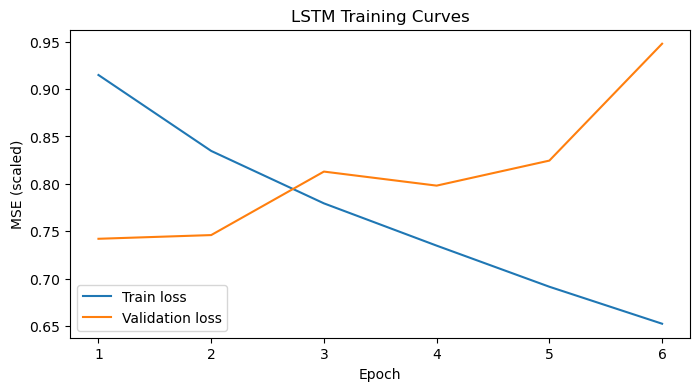

In [16]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(history['train']) + 1), history['train'], label='Train loss')
plt.plot(range(1, len(history['val']) + 1), history['val'], label='Validation loss')
plt.title('LSTM Training Curves')
plt.xlabel('Epoch')
plt.ylabel('MSE (scaled)')
plt.legend()
plt.show()

## Fair Comparison on the Test Set

The LSTM's predictions are converted back to kW (undo scaling, then add the predicted change to the current power).

All three models (naive, XGBoost, LSTM) are then scored on **exactly the same test rows**: the timestamps where a full, gap-free 6-hour sequence exists. XGBoost's predictions are loaded from notebook 04.

In [17]:
def predict(X_seq, batch_size=1024):
    """Run the model on sequences in batches and return scaled predictions."""
    model.eval()
    outputs = []
    with torch.no_grad():
        for i in range(0, len(X_seq), batch_size):
            batch = torch.from_numpy(X_seq[i:i + batch_size]).to(device)
            outputs.append(model(batch).cpu().numpy())
    return np.concatenate(outputs)

# Convert predicted change back to kW, then add to current power
delta_kw = target_scaler.inverse_transform(predict(X_test_seq).reshape(-1, 1)).ravel()
current_power = test['power'].values[test_ends]
lstm_pred = np.clip(current_power + delta_kw, 0, train['power'].max())

# Load naive and XGBoost predictions for exactly the same timestamps
test_timestamps = test.index[test_ends]
preds = pd.read_csv('../data/processed/wind_test_predictions.csv', index_col='timestamp', parse_dates=True)
preds = preds.loc[test_timestamps]
preds['lstm'] = lstm_pred

def score(pred, name):
    return {'Model': name,
            'MAE (kW)': round(mean_absolute_error(preds['actual'], pred), 1),
            'RMSE (kW)': round(np.sqrt(mean_squared_error(preds['actual'], pred)), 1)}

comparison = pd.DataFrame([
    score(preds['naive'], 'Naive (persistence)'),
    score(preds['xgboost_delta'], 'XGBoost (predicts change)'),
    score(preds['lstm'], 'LSTM (predicts change)'),
])
naive_rmse = comparison.loc[0, 'RMSE (kW)']
comparison['Skill vs. naive'] = (1 - comparison['RMSE (kW)'] / naive_rmse).round(3)

print(f'Evaluated on {len(preds)} test rows (Nov–Dec 2018)')
comparison

Evaluated on 7943 test rows (Nov–Dec 2018)


,Model,MAE (kW),RMSE (kW),Skill vs. naive
0,Naive (persistence),285.9,494.1,0.000
1,XGBoost (predicts change),311.9,477.6,0.033
2,LSTM (predicts change),314.7,479.5,0.030


## Forecast vs. Actual (First Week of Test Period)

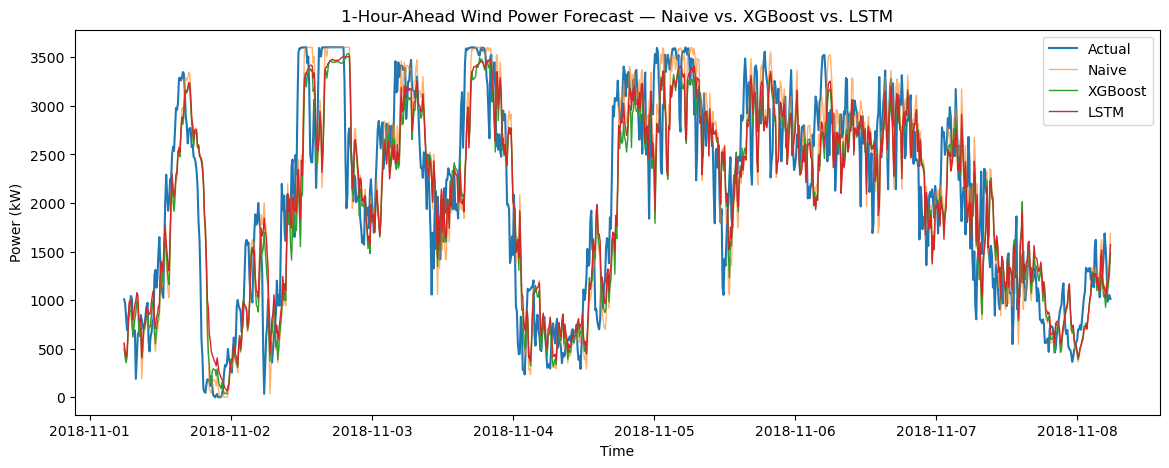

In [18]:
week = preds.index < preds.index[0] + pd.Timedelta(days=7)

plt.figure(figsize=(14, 5))
plt.plot(preds.index[week], preds['actual'][week], label='Actual', linewidth=1.5)
plt.plot(preds.index[week], preds['naive'][week], label='Naive', linewidth=1, alpha=0.6)
plt.plot(preds.index[week], preds['xgboost_delta'][week], label='XGBoost', linewidth=1)
plt.plot(preds.index[week], preds['lstm'][week], label='LSTM', linewidth=1)
plt.title('1-Hour-Ahead Wind Power Forecast — Naive vs. XGBoost vs. LSTM')
plt.xlabel('Time')
plt.ylabel('Power (kW)')
plt.legend()
plt.show()

## Save the Model and Preprocessing

The LSTM weights and everything needed to reuse the model later (scalers, feature list, sequence length) are saved for the Streamlit dashboard. The combined predictions are saved for the final comparison.

In [19]:
import joblib

torch.save(model.state_dict(), '../models/wind_lstm.pt')
joblib.dump({
    'feature_scaler': feature_scaler,
    'target_scaler': target_scaler,
    'features': FEATURES,
    'seq_len': SEQ_LEN
}, '../models/wind_lstm_preprocessing.joblib')

preds.to_csv('../data/processed/wind_test_predictions_all.csv')
print('Saved LSTM model, preprocessing, and combined test predictions.')

Saved LSTM model, preprocessing, and combined test predictions.


## Results & Conclusions

**Test results (Nov–Dec 2018, 1-hour-ahead forecast)**, with all models scored on the same 7,943 rows where a full 6-hour gap-free sequence exists:

| Model | MAE (kW) | RMSE (kW) | Skill vs. naive |
|---|---|---|---|
| Naive (persistence) | 285.9 | 494.1 | 0.000 |
| **XGBoost (predicts change) ✅** | 311.9 | **477.6** | **0.033** |
| LSTM (predicts change) | 314.7 | 479.5 | 0.030 |

*(XGBoost's figures differ slightly from notebook 04 because they are computed on this common subset of test rows.)*

**Key findings:**
1. **Both models beat persistence on RMSE by about 3%, and are essentially tied.** XGBoost is marginally better, trains in seconds rather than minutes, and is easier to interpret, so it is the practical choice.
2. **Neither beats persistence on MAE.** The models add value on larger swings in output, but in steady conditions "same as now" is already close to exact.
3. **More model capacity didn't help.** The LSTM overfit after its first epoch, and a smaller, more regularised version did not generalise better. The input features already summarise recent history (lags, rolling averages, trends), so reading the raw 6-hour sequence adds little new information.
4. **The limit is the information available, not the model.** Forecasting from past observations alone leaves little predictable signal one hour ahead. The most promising improvement is adding weather-forecast inputs (predicted wind speed), not a bigger model.